# The Machine Learning Toolkit 🧰🌸
### Meet the Python Libraries Every ML Practitioner Uses (Iris Dataset)

Before we dive deeper into training models, let's get familiar with the **tools of the trade**.
Almost every ML project in Python uses the same core set of libraries. In this notebook,
we'll introduce each one and see exactly what job it does — using the Iris dataset throughout.

**The Toolkit:**
1. **NumPy** — fast numerical arrays and math
2. **pandas** — tables (DataFrames) for organizing and exploring data
3. **Matplotlib & Seaborn** — data visualization
4. **scikit-learn** — the ML models, splitting tools, and evaluation metrics themselves

Think of these like a chef's kitchen tools: NumPy is the cutting board and knife (raw prep),
pandas is the organized ingredient tray, Matplotlib/Seaborn are the plating and presentation,
and scikit-learn is the oven that actually "cooks" the model.


## 1. NumPy — Numerical Computing

**What it's for:** NumPy gives Python fast, efficient arrays and math operations.
Under the hood, almost every ML library (including pandas and scikit-learn) is built on top of NumPy arrays.

Let's see it directly on Iris data.


In [1]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()

# iris.data is already a NumPy array!
print("Type:", type(iris.data))
print("Shape:", iris.data.shape)   # (150 rows, 4 columns)
print()
print("First 3 rows:")
print(iris.data[:3])


Type: <class 'numpy.ndarray'>
Shape: (150, 4)

First 3 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


In [2]:
# NumPy makes math over entire arrays fast and easy — no manual loops needed
petal_lengths = iris.data[:, 2]   # column index 2 = petal length

print("Mean petal length:", np.mean(petal_lengths))
print("Max petal length: ", np.max(petal_lengths))
print("Min petal length: ", np.min(petal_lengths))
print("Std deviation:    ", np.std(petal_lengths))


Mean petal length: 3.7580000000000005
Max petal length:  6.9
Min petal length:  1.0
Std deviation:     1.759404065775303


**Key idea:** NumPy operations work on the *whole array at once* (this is called "vectorization"),
which is why it's much faster than writing a manual `for` loop over each value.


## 2. pandas — Organizing Data into Tables

**What it's for:** pandas turns raw arrays into labeled tables (called **DataFrames**),
similar to an Excel spreadsheet — with column names, row indices, and powerful filtering tools.


In [3]:
import pandas as pd

# Convert the NumPy array into a labeled DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Series(iris.target).map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# pandas makes filtering and grouping easy
# Example: show only flowers with petal length > 5cm
large_petals = df[df['petal length (cm)'] > 5]
print(f"Flowers with petal length > 5cm: {len(large_petals)}")
large_petals.head()


Flowers with petal length > 5cm: 42


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
83,6.0,2.7,5.1,1.6,versicolor
100,6.3,3.3,6.0,2.5,virginica
101,5.8,2.7,5.1,1.9,virginica
102,7.1,3.0,5.9,2.1,virginica
103,6.3,2.9,5.6,1.8,virginica


In [5]:
# Group by species and see average measurements per group
df.groupby('species').mean(numeric_only=True)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


**Key idea:** if NumPy is about raw numbers, pandas is about *labeled, organized, filterable* data —
this is almost always your first stop when exploring a new dataset.


## 3. Matplotlib & Seaborn — Visualization

**What they're for:** Turning numbers into pictures. Matplotlib is the foundational plotting library;
Seaborn is built on top of it and makes statistical plots easier and prettier.


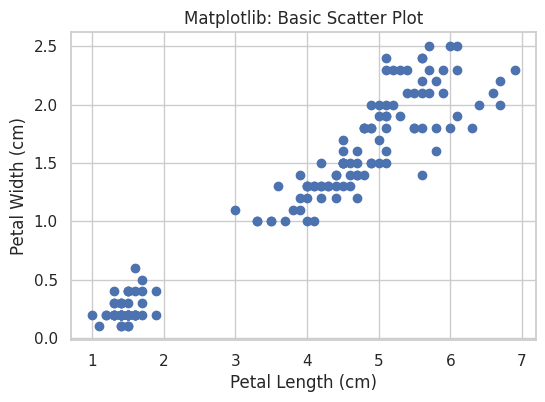

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# A simple Matplotlib plot
plt.figure(figsize=(6, 4))
plt.scatter(df['petal length (cm)'], df['petal width (cm)'])
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Matplotlib: Basic Scatter Plot')
plt.show()


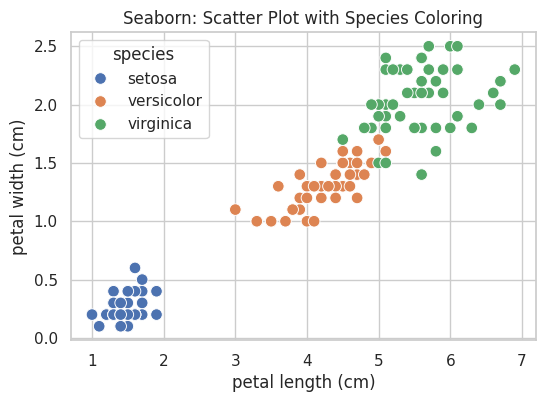

In [7]:
# The same idea, but with Seaborn — one line of code adds color-by-species and styling
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='species', s=70)
plt.title('Seaborn: Scatter Plot with Species Coloring')
plt.show()


**Key idea:** Matplotlib gives you full control (good for custom plots), while Seaborn gives you
faster, better-looking statistical plots with less code (good for quick exploration).


## 4. scikit-learn — The ML Engine

**What it's for:** scikit-learn (`sklearn`) provides the actual machine learning tools —
datasets, train/test splitting, models (KNN, Decision Trees, etc.), and evaluation metrics —
all with a **consistent, simple interface**.

Almost every scikit-learn model follows the same 3-step pattern:
```
model = SomeModel()      # 1. Create the model
model.fit(X_train, y)    # 2. Train it
model.predict(X_new)     # 3. Use it to predict
```


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = df[iris.feature_names]
y = pd.Series(iris.target)

# Splitting tool
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model: create -> fit -> predict (the standard scikit-learn pattern)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Evaluation tool
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")


Accuracy: 100.00%


**Key idea:** scikit-learn is organized into modules that mirror the ML process itself:
`sklearn.model_selection` (splitting), `sklearn.neighbors` / `sklearn.tree` / etc. (models),
and `sklearn.metrics` (evaluation) — matching the stages from our "ML Process" notebook!


## How the Toolkit Fits Together

```
Raw Data
   │
   ▼
NumPy (arrays, math)
   │
   ▼
pandas (organize into a table, explore, filter)
   │
   ▼
Matplotlib / Seaborn (visualize patterns)
   │
   ▼
scikit-learn (split → train → predict → evaluate)
```

Every notebook in this course uses this exact stack. Getting comfortable with these four
libraries is 90% of the "engineering" work in a beginner ML project — the algorithms themselves
are often just a couple lines of code once the data is ready.


## Recap: The Toolkit

| Library | Nickname | Main Job |
|---|---|---|
| NumPy | The calculator | Fast numerical arrays and math |
| pandas | The spreadsheet | Organize, filter, and summarize data in tables |
| Matplotlib | The sketchpad | Foundational plotting |
| Seaborn | The stylist | Prettier, statistical plots with less code |
| scikit-learn | The workshop | Splitting, models, training, evaluation |

---

## 🧪 Try It Yourself

1. Use NumPy to find the **median** sepal width (`np.median(...)`).
2. Use pandas to filter for only `species == 'setosa'` flowers and count how many there are.
3. Make your own Seaborn plot comparing `sepal length` vs `sepal width`, colored by species.
4. Swap `KNeighborsClassifier` for `from sklearn.tree import DecisionTreeClassifier` in the scikit-learn example — notice how little code changes thanks to the consistent `fit`/`predict` pattern.
